# An Arbitrage-Free Neural Implied-Volatility Surface

**Marco** · [github.com/…/volsurface](.) · MIT

---

### Abstract

Fitting an implied-volatility surface to a listed option chain forces a choice
between two failures. Calibrating **SVI** independently to each expiry tracks
every smile closely but leaves the slices unconnected, so interpolating between
them prices calendar-spread arbitrage. Calibrating a joint **SSVI** surface makes
calendar arbitrage impossible by construction but is far too rigid for a real
chain, whose smile changes character between the front week and the one-year
point.

This notebook builds a third option: a neural network that learns a *bounded
multiplicative correction* to a calibrated SSVI prior, trained under
no-arbitrage penalties differentiated by autograd and enforced on collocation
points that extend beyond the quoted strikes. Positivity, sane extrapolation and
an a-priori error bound come from the architecture rather than from the
optimiser.

On a live SPY chain the result fits **1.6× closer than per-slice SVI and 3.7×
closer than joint SSVI**, wins in price space as well as in volatility space,
and is free of static arbitrage where per-slice SVI violates the calendar
condition on ~1% of the plane.

A second result falls out of the data pipeline rather than the model. SPY
options are **American**; inverting a European formula on them charges the
early-exercise premium to volatility. That bias is ~13bp of vol on average and
~25bp beyond one year — larger than the fit error being measured — and it sits
almost entirely in the puts. The quotes are de-Americanised on a binomial
lattice before the surface ever sees them.

---

### Contents

| | |
|---|---|
| **1** | [Setup](#1) |
| **2** | [From broker quotes to a volatility point cloud](#2) |
| **3** | [The American problem](#3) |
| **4** | [The parametric baselines](#4) |
| **5** | [The neural surface](#5) |
| **6** | [Results](#6) |
| **7** | [Using the fitted surface](#7) |
| **8** | [Reproducing this](#8) |

<a id="1"></a>
## 1. Setup

Everything lives in one package. `LIVE = False` swaps the live chain for one
generated from a known arbitrage-free SSVI surface, which makes the whole
notebook run without network access — and is genuinely useful, because any
arbitrage the diagnostics report on generated data is a defect in the *model*
rather than a feature of the market.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import volsurface as vs

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4.5), "font.size": 9})

LIVE   = True      # False -> generated chain, no network needed
TICKER = "SPY"
EPOCHS = 1500

print("volsurface", vs.__version__)

volsurface 1.0.0


<a id="2"></a>
## 2. From broker quotes to a volatility point cloud

The quality of a vol surface is decided in the data pipeline, not in the model.
`fetch_chain` downloads the raw chain and does five things explicitly rather
than delegating them to the data vendor:

1. **Liquidity filtering** — two-sided quotes only, positive size, and a cap on
   the relative bid-ask spread. Stale or one-sided rows produce implied vols
   that no model should be asked to fit.

2. **Forward and discount factor implied from the market.** Rather than
   assuming $F = S e^{(r-q)T}$ with a guessed dividend yield, put-call parity
   $$C(K) - P(K) = \mathrm{DF}\,(F - K)$$
   is a straight line in $K$ with slope $-\mathrm{DF}$ and intercept
   $\mathrm{DF}\cdot F$. A weighted regression over the liquid matched strikes
   returns both. This is what removes the systematic skew tilt a wrong dividend
   assumption produces.

3. **Out-of-the-money quotes only** — calls above the forward, puts below it.
   Those are the liquid instruments; the in-the-money wing carries the same
   information with a wider spread, and taking both would double-count each
   strike.

4. **In-house IV inversion**, from $\mathrm{mid}/\mathrm{DF}$ in the forward
   measure, so the vols are consistent with the forward fitted in step 2 rather
   than with a vendor's own rate and dividend assumptions.

5. **De-Americanisation** — section 3.

Expiries are sampled evenly in $\sqrt{T}$ across the *whole* listed term
structure. Taking the first eight would give eight expiries inside three months
and no term structure at all, and the calendar-arbitrage condition is a
statement across maturities.

In [2]:
try:
    chain = vs.fetch_chain(TICKER, max_expiries=8) if LIVE else None
    live = chain is not None
except Exception as exc:
    print(f"live chain unavailable ({exc}); using a generated one")
    chain, live = None, False

if chain is None:
    chain = vs.synthetic_snapshot(ticker=TICKER, noise_bps=25.0)

print(chain.summary())
print("\nsource:", "live option chain" if live else "GENERATED (synthetic)")

SPY @ 2026-08-29  spot=771.10
  1400 quotes across 8 expiries (0.036y - 1.800y)
  k range [-0.997, +0.584]  IV range [8.7%, 65.7%]

source: live option chain


The forward and discount factor recovered per expiry. `r` and `q` are not inputs
— they are read back out of the fitted `F` and `DF`, so the lattice used later
and the surface cannot disagree about the forward.

In [3]:
rows = []
for T in chain.maturities:
    F, DF = chain.forwards[T], chain.discounts[T]
    r, q = vs.carry_from_forward(chain.spot, F, DF, T)
    sl = chain.slice_at(T)
    rows.append({
        "T (years)": round(T, 4),
        "quotes": len(sl),
        "forward": round(F, 3),
        "DF": round(DF, 5),
        "implied r": f"{r:.3%}",
        "implied q": f"{q:.3%}",
        "ATM vol": f"{np.interp(0.0, np.sort(sl.k), sl.iv[np.argsort(sl.k)]):.2%}",
    })
pd.DataFrame(rows)

,T (years),quotes,forward,DF,implied r,implied q,ATM vol
0,0.0356,139,770.005,1.00477,-13.365%,-9.376%,10.12%
1,0.1315,182,771.085,1.01006,-7.609%,-7.594%,12.41%
2,0.2548,180,774.868,0.99967,0.131%,-1.782%,13.56%
3,0.4192,161,779.430,0.99527,1.131%,-1.432%,14.39%
4,0.8000,164,791.483,0.97984,2.546%,-0.715%,15.86%
5,1.0521,179,799.787,0.96471,3.415%,-0.057%,16.65%
6,1.3973,196,810.566,0.94240,4.246%,0.674%,16.95%
7,1.8000,199,825.098,0.92257,4.477%,0.717%,17.26%


The point cloud the models have to explain. Log-moneyness $k=\log(K/F_T)$ on the
horizontal axis; each colour is one expiry. Note how much wider the quoted
strike range is at long maturities — and how little of the plane is actually
covered by quotes.

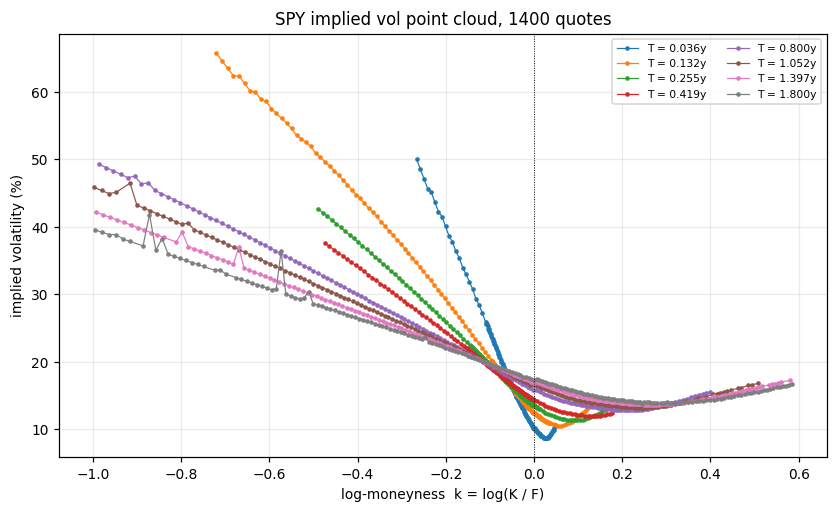

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for T in chain.maturities:
    sl = chain.slice_at(T)
    o = np.argsort(sl.k)
    ax.plot(sl.k[o], sl.iv[o] * 100, ".-", ms=4, lw=0.8, label=f"T = {T:.3f}y")
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel("log-moneyness  k = log(K / F)")
ax.set_ylabel("implied volatility (%)")
ax.set_title(f"{chain.ticker} implied vol point cloud, {len(chain)} quotes")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.25)
plt.show()

Quotes are not equally informative. Each carries a fitting weight of roughly
**vega / spread** — how much price information one volatility point carries,
divided by how uncertain that price is. Unweighted least squares in vol space
chases deep wing options whose volatility is barely identified by their price,
at the expense of the at-the-money region where the money is.

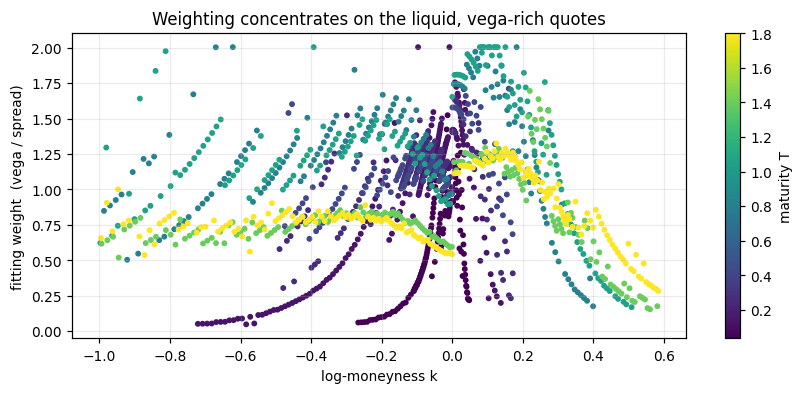

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
sc = ax.scatter(chain.k, chain.weight, c=chain.T, s=8, cmap="viridis")
ax.set_xlabel("log-moneyness k")
ax.set_ylabel("fitting weight  (vega / spread)")
ax.set_title("Weighting concentrates on the liquid, vega-rich quotes")
ax.grid(alpha=0.25)
plt.colorbar(sc, ax=ax, label="maturity T")
plt.show()

<a id="3"></a>
## 3. The American problem

Listed equity and ETF options — SPY included — are **American**. Their quoted
prices contain an early-exercise premium, and a European Black-Scholes inversion
has nowhere to put it, so it is charged to volatility instead. The bias is not
uniform: it lives in the puts (where interest earned on the strike makes early
exercise valuable) and grows with maturity and with rates.

The correction prices the premium on a binomial lattice and strips it out:

$$\sigma \;\leftarrow\; \mathrm{IV}_{\mathrm{BS}}\!\Big(\text{price} -
\big[\mathrm{CRR}_{\text{amer}}(\sigma) - \mathrm{CRR}_{\text{euro}}(\sigma)\big]\Big)$$

iterated to a fixed point. Two details make this the right construction rather
than re-solving the inversion on the lattice:

* The premium is a **difference of two prices off the same lattice at the same
  $\sigma$**, so the tree's discretisation error cancels almost exactly. What
  survives is the premium — the only quantity being asked for — which is why 150
  steps suffice where pricing to that accuracy would need far more.
* The final inversion is the **exact** Black-Scholes one. A single vega-linearised
  Newton step is fine for the few-basis-point premia of short-dated calls and
  badly wrong for a long-dated put, where the premium can exceed a whole
  volatility point.

In [6]:
print(chain.early_exercise_summary())

  removed 13.27bp of vol on average (median 0.99, p95 67.85, max 262.53)
    calls   0.27bp mean   puts  20.16bp mean
    T in [0.00, 0.15)  n= 321  mean   0.41bp  p95   2.38bp
    T in [0.15, 0.50)  n= 341  mean   7.43bp  p95  26.88bp
    T in [0.50, 1.00)  n= 164  mean  10.98bp  p95  50.63bp
    T >= 1.00          n= 574  mean  24.59bp  p95 116.61bp


Plotted, the structure is unmistakable — and it is exactly what theory predicts.

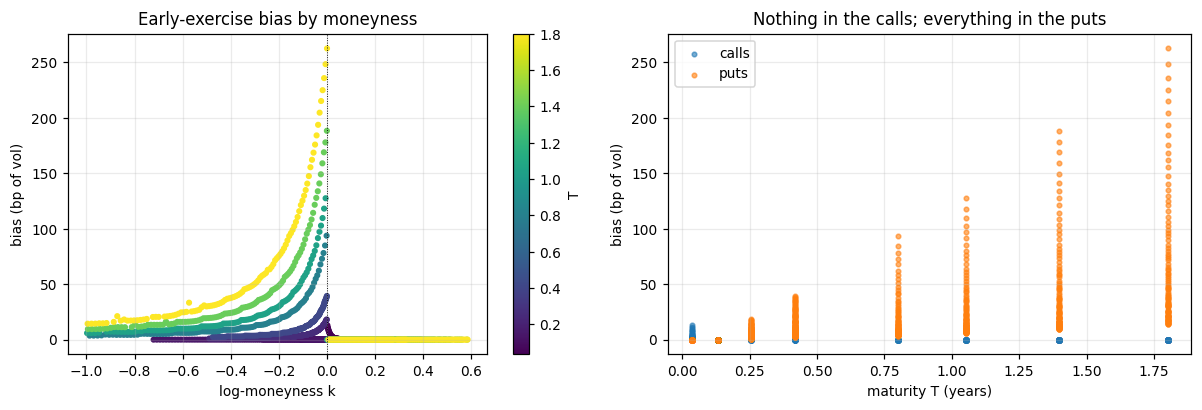

In [7]:
bias = chain.early_exercise_bp
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

sc = axes[0].scatter(chain.k, bias, c=chain.T, s=9, cmap="viridis")
axes[0].set_xlabel("log-moneyness k"); axes[0].set_ylabel("bias (bp of vol)")
axes[0].set_title("Early-exercise bias by moneyness")
axes[0].axvline(0, color="k", lw=0.6, ls=":")
plt.colorbar(sc, ax=axes[0], label="T")

for lab, mask in (("calls", chain.is_call), ("puts", ~chain.is_call)):
    axes[1].scatter(chain.T[mask], bias[mask], s=9, alpha=0.6, label=lab)
axes[1].set_xlabel("maturity T (years)"); axes[1].set_ylabel("bias (bp of vol)")
axes[1].set_title("Nothing in the calls; everything in the puts")
axes[1].legend()

for a in axes:
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

This has a second consequence that is easy to miss. **Put-call parity is a
theorem about European options.** The forward fitted in step 2 of the pipeline
came from raw American mids, so it is biased too — by close to 1% of the forward
on an 18-month expiry, which tilts the entire fitted skew.

The two unknowns are circular: you need the forward to de-Americanise a quote,
and de-Americanised quotes to fit the forward. `fit_forward` therefore runs them
as a short fixed point — fit, strip the premia, refit — and two passes cut the
forward error by about a factor of seven.

Below, a controlled experiment: quotes priced as genuine American options at a
known 25% vol, then run back through the pipeline both ways.

In [8]:
from datetime import date
from volsurface.pricing.american import binomial_price, carry_from_forward
from volsurface.data import build_snapshot

SIG, T_ = 0.25, 546 / 365.0
S_, r_, q_ = 100.0, 0.045, 0.010
F_, DF_ = S_ * np.exp((r_ - q_) * T_), float(np.exp(-r_ * T_))
strikes = np.arange(70.0, 136.0, 5.0)

def frame(px):
    return pd.DataFrame({"strike": strikes, "bid": np.maximum(px - 0.05, 0.01),
                         "ask": px + 0.05, "openInterest": 500, "volume": 100})

amer = lambda opt: np.array([binomial_price(S_, K, T_, r_, SIG, opt, style="american",
                                            n_steps=400, q=q_)["price"] for K in strikes])
chains = {"2026-07-02": (frame(amer("call")), frame(amer("put")))}

out = []
for flag in (False, True):
    snap = build_snapshot("TEST", S_, date(2025, 1, 2), chains, max_rel_spread=1.0,
                          de_americanize=flag, lattice_steps=200)
    Tk = snap.maturities[0]
    out.append({
        "de-Americanised": flag,
        "forward":  round(snap.forwards[Tk], 4),
        "forward error": round(abs(snap.forwards[Tk] - F_), 4),
        "DF error": round(abs(snap.discounts[Tk] - DF_), 5),
        "worst IV error (bp)": round(np.abs(snap.iv - SIG).max() * 1e4, 1),
    })
print(f"truth:  forward = {F_:.4f}   DF = {DF_:.5f}   vol = {SIG:.0%}\n")
pd.DataFrame(out)

truth:  forward = 105.3751   DF = 0.93490   vol = 25%



,de-Americanised,forward,forward error,DF error,worst IV error (bp)
0,False,104.4833,0.8918,0.04140,44.6
1,True,105.2485,0.1266,0.00564,17.5


<a id="4"></a>
## 4. The parametric baselines

Both models are stated in **total implied variance** $w(k,T)=\sigma(k,T)^2 T$.
That is not a stylistic choice: both static no-arbitrage conditions are clean
statements about $w$ and ugly ones about $\sigma$, and $w$ is the quantity that
must vanish at $T\to0$ and grow with maturity.

**Raw SVI** (Gatheral 2004) fits one smile at a time, five parameters per expiry:

$$w(k) = a + b\Big[\rho\,(k-m) + \sqrt{(k-m)^2 + \sigma^2}\Big]$$

**SSVI** (Gatheral & Jacquier 2014) makes every slice a function of a single ATM
variance $\theta$, with three global parameters:

$$w(k,\theta) = \frac{\theta}{2}\Big\{1 + \rho\varphi(\theta)k +
\sqrt{(\varphi(\theta)k+\rho)^2 + 1-\rho^2}\Big\},\qquad
\varphi(\theta) = \frac{\eta}{\theta^{\gamma}(1+\theta)^{1-\gamma}}$$

With $\theta(T)$ non-decreasing, SSVI is provably free of calendar-spread
arbitrage.

> **A calibration trap.** A direct five-parameter search over
> $(a,b,\rho,m,\sigma)$ does not work, and the failure is not subtle: the
> objective has long flat valleys where $\rho\to-1$ trades off against
> $\sigma\to0$, and a simplex started at a fixed point walks into them and
> returns a degenerate slice with a large negative $a$. It looks converged and
> prices nonsense. The implementation here uses the **Zeliade quasi-explicit**
> method: for fixed $(m,\sigma)$ the model is *linear* in the rest, so a
> constrained linear least squares sits inside a two-dimensional multi-start
> search.

In [9]:
svi  = vs.SVISliceSurface.fit(chain)
ssvi = vs.SSVISurface.fit(chain)

print(f"SSVI global parameters:  rho={ssvi.params.rho:+.4f}  "
      f"eta={ssvi.params.eta:.4f}  gamma={ssvi.params.gamma:.4f}\n")

pd.DataFrame([{
    "expiry T": round(T, 4), **{k: round(v, 4) for k, v in vars(p).items()}
} for T, p in svi.params.items()])

SSVI global parameters:  rho=-0.5823  eta=1.3281  gamma=0.4967



,expiry T,a,b,rho,m,sigma
0,0.0356,0.0,0.0194,-1.0000,-0.0573,0.0534
1,0.1315,0.0,0.0409,-1.0000,-0.0840,0.1104
2,0.2548,0.0,0.0534,-0.8787,-0.0503,0.1249
3,0.4192,0.0,0.0695,-0.8515,-0.0391,0.1563
4,0.8000,0.0,0.1103,-0.9528,-0.1260,0.2873
5,1.0521,0.0,0.1238,-0.8676,-0.0845,0.2955
6,1.3973,0.0,0.1391,-0.7145,-0.0039,0.2852
7,1.8000,0.0,0.1589,-0.6564,0.0327,0.3089


Now the point of the whole project. Score each baseline on **fit** and on
**static arbitrage**, using the same code.

* Calendar spread: $\partial w/\partial T \ge 0$. A violation means a
  longer-dated option is worth less than a shorter-dated one at the same
  relative moneyness.
* Butterfly: Durrleman's condition
  $$g(k,T) = \Big(1 - \tfrac{k\,w_k}{2w}\Big)^2 - \tfrac{w_k^2}{4}\Big(\tfrac14 + \tfrac1w\Big) + \tfrac{w_{kk}}{2} \ \ge\ 0$$
  A violation means the surface prices a negative probability density.

Both are checked on a dense grid that deliberately extends **beyond** the quoted
strikes. A surface that is arbitrage-free only where it saw data is not usable
for interpolation.

In [10]:
for surf in (svi, ssvi):
    score = vs.evaluate_surface(surf, chain)
    print(f"{surf.name}")
    print(f"   fit  {score.fit}")
    print(f"   arb  {score.arb}\n")

SVI (per-slice)
   fit  n=1400  IV RMSE=49.3bp  MAE=35.0bp  max=558.4bp  price RMSE=0.5783  inside spread=5.6%
   arb  calendar 60/7381 (0.81%), worst dw/dT=-2.36e-03 at k=+0.901 T=0.482; butterfly 4/7381 (0.05%), worst g=-5.56e-02 at k=-0.114 T=0.018

SSVI (joint)
   fit  n=1400  IV RMSE=115.8bp  MAE=87.3bp  max=1414.8bp  price RMSE=1.0710  inside spread=2.1%
   arb  arbitrage-free on 7381 grid points



Per-slice SVI fits far better and admits arbitrage; SSVI is clean and cannot
follow the chain. That is the trade-off, measured.

<a id="5"></a>
## 5. The neural surface

### Architecture

The network does **not** output implied vol, and it does not output total
variance either. It outputs a **bounded multiplicative correction** to the
calibrated SSVI prior:

$$w(k,T) \;=\; w_{\mathrm{SSVI}}(k,T)\,\Big[\,1 + \alpha\tanh\big(\mathrm{net}(k,T)\big)\Big]$$

Three consequences follow from that one line, and they are the whole design:

* **Positivity is structural.** $w_{\mathrm{SSVI}}>0$ and the bracket lives in
  $[1-\alpha,\,1+\alpha]$ with $\alpha<1$, so $w>0$ everywhere by construction.
  No penalty, no clamping, no `NaN` in $\sqrt{w}$.
* **Extrapolation degrades to SSVI, not to noise.** Far outside the quoted
  strikes the network saturates and the surface becomes a fixed multiple of an
  arbitrage-free parametric surface. An unconstrained net asked for $w$ directly
  produces whatever its last hidden layer happens to extrapolate to — which is
  how neural vol surfaces end up pricing negative densities two strikes past the
  last quote.
* **The error is bounded a priori.** With $\alpha=0.35$ the fitted surface is
  never more than ~16% away from SSVI in vol terms. That is a statement you can
  make to a risk officer before the model has seen any data.

The output layer is zero-initialised, so training *starts* exactly at the prior
and a failed run degrades to SSVI rather than to garbage.

**Features.** $(k,T)$ is a poor input basis. The smile does not live in
log-moneyness, it lives in *standardised* log-moneyness $z = k/\sqrt{T}$ — the
coordinate in which smiles across maturities look alike. The feature vector is
$(k,\ \sqrt{T},\ k/\sqrt{T},\ k^2,\ k\sqrt{T})$, standardised on the training
chain.

### Constraints

$$\mathcal{L} \;=\; \underbrace{\sum_i w_i\big(\sigma_{\text{model}}(k_i,T_i)-\sigma^{\text{mkt}}_i\big)^2}_{\text{vega-weighted, in vol space}}
\;+\; \lambda_{\text{cal}}\,\overline{\mathrm{relu}(-\partial_T w)^2}
\;+\; \lambda_{\text{bfly}}\,\overline{\mathrm{relu}(-g)^2}$$

Each penalty is zero wherever the condition holds and quadratic in the depth of
the breach. Every derivative comes from `torch.autograd` with
`create_graph=True` — exact, with no finite-difference error floor to tune
tolerances against.

**Where the penalties are evaluated matters more than their weight.** They are
imposed on random *collocation points* over a region 30% wider in strike than
the quotes and past the last listed expiry, **resampled every epoch**.
Constraining the surface only where quotes exist is nearly free and nearly
useless: the wings and the gaps between expiries are exactly where an
interpolating network invents negative densities. Resampling stops the network
from satisfying the constraint at a fixed set of locations while violating it
between them.

This is also why the model runs in float64 with a smooth activation: the
butterfly penalty differentiates the network twice, and a ReLU network has zero
second derivative almost everywhere.

### Validation split

The held-out set is **stratified within each expiry** — every $n$-th strike of
every smile. A plain random split leaves validation points surrounded by
training points a few strikes away, so any interpolator scores well and you
learn nothing. Holding out whole expiries tests extrapolation in maturity, a
genuinely different and much harder task. Stratifying within each expiry tests
what a surface is actually used for: pricing a strike that is not listed.

In [11]:
cfg = vs.TrainConfig(epochs=EPOCHS, log_every=max(EPOCHS // 6, 1))
result = vs.train_surface(chain, cfg)
print()
print(result.summary())

  epoch     0  loss=1.349e-04  train=  115.4bp  val=  113.5bp  worst dw/dT=+1.03e-02  worst g=+2.51e-01


  epoch   250  loss=1.628e-05  train=   40.4bp  val=   35.4bp  worst dw/dT=+6.30e-03  worst g=+2.36e-03


  epoch   500  loss=1.290e-05  train=   35.9bp  val=   29.8bp  worst dw/dT=+6.46e-03  worst g=+7.24e-03


  epoch   750  loss=1.186e-05  train=   34.4bp  val=   28.2bp  worst dw/dT=+1.16e-02  worst g=+5.28e-03


  epoch  1000  loss=1.118e-05  train=   33.4bp  val=   27.2bp  worst dw/dT=+1.11e-02  worst g=+6.05e-03


  epoch  1250  loss=1.088e-05  train=   33.0bp  val=   26.7bp  worst dw/dT=+1.15e-02  worst g=+2.29e-03



trained 1500 epochs in 81.9s (best epoch 1460)
  train IV RMSE 32.9bp  val IV RMSE 26.6bp  (n_train=1120, n_val=280)
  final worst dw/dT +1.12e-02  worst g +1.81e-03


The training history shows what the penalties are doing. The worst violation
found on the collocation points is driven to zero and held there while the fit
error keeps falling — the constraints are binding early and then costless.

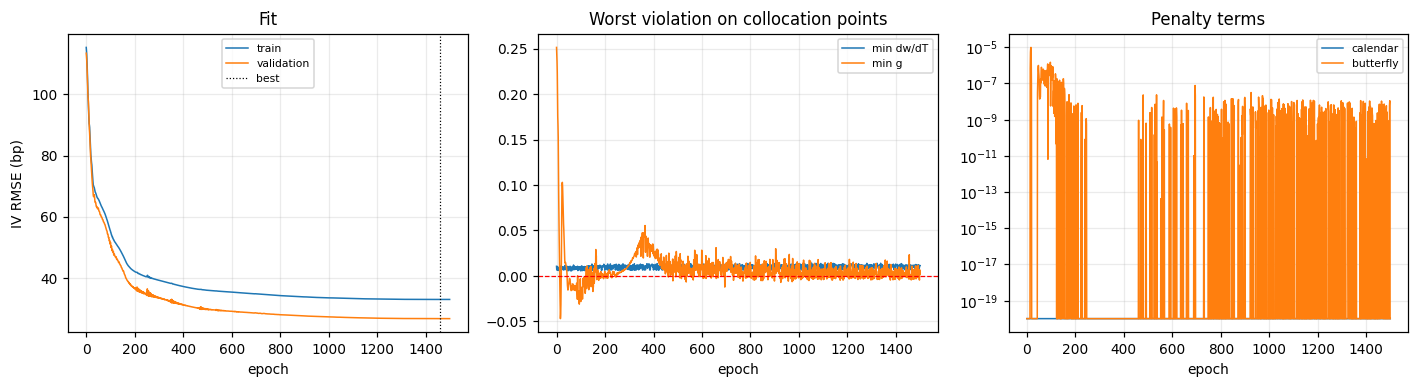

In [12]:
h = result.history
ep = np.arange(len(h["train_rmse_bps"]))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

axes[0].plot(ep, h["train_rmse_bps"], lw=1, label="train")
axes[0].plot(ep, h["val_rmse_bps"], lw=1, label="validation")
axes[0].axvline(result.best_epoch, color="k", ls=":", lw=0.8, label="best")
axes[0].set_ylabel("IV RMSE (bp)"); axes[0].set_title("Fit"); axes[0].legend(fontsize=7)

axes[1].plot(ep, h["worst_calendar"], lw=1, label="min dw/dT")
axes[1].plot(ep, h["worst_butterfly"], lw=1, label="min g")
axes[1].axhline(0, color="r", lw=0.8, ls="--")
axes[1].set_title("Worst violation on collocation points"); axes[1].legend(fontsize=7)

axes[2].semilogy(ep, np.maximum(h["pen_calendar"], 1e-20), lw=1, label="calendar")
axes[2].semilogy(ep, np.maximum(h["pen_butterfly"], 1e-20), lw=1, label="butterfly")
axes[2].set_title("Penalty terms"); axes[2].legend(fontsize=7)

for a in axes:
    a.set_xlabel("epoch"); a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

How far did the network actually move from its prior? The correction is bounded
by $\alpha$ by construction; in practice it uses a fraction of that budget, and
uses it where the quotes are.

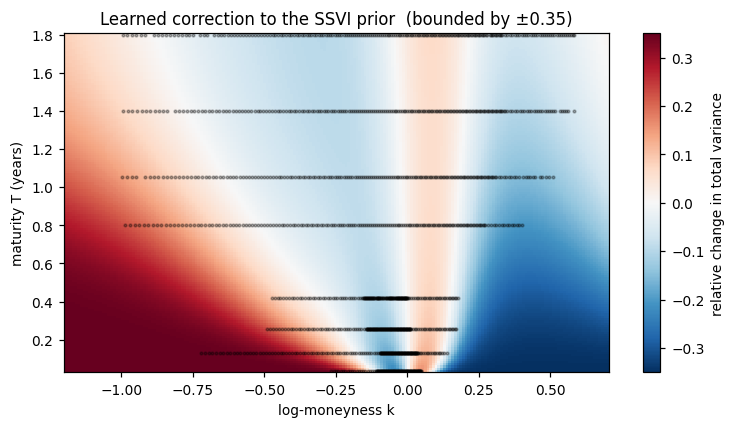

budget                +/-0.35
over the whole plane  min -0.349  max +0.350  saturated on 5.5% of it
at the 1400 quotes    min -0.231  max +0.349  saturated on 0.6% of them


In [13]:
import torch

kk, TT = np.meshgrid(np.linspace(chain.k.min() * 1.2, chain.k.max() * 1.2, 200),
                     np.linspace(chain.T.min(), chain.T.max(), 150), indexing="ij")
with torch.no_grad():
    corr = result.model.correction(
        torch.tensor(kk.ravel(), dtype=torch.float64),
        torch.tensor(TT.ravel(), dtype=torch.float64),
    ).numpy().reshape(kk.shape)

fig, ax = plt.subplots(figsize=(8, 4))
lim = result.model.config.alpha
im = ax.pcolormesh(kk, TT, corr - 1.0, cmap="RdBu_r", vmin=-lim, vmax=lim, shading="auto")
ax.scatter(chain.k, chain.T, s=3, c="k", alpha=0.3)
ax.set_xlabel("log-moneyness k"); ax.set_ylabel("maturity T (years)")
ax.set_title(f"Learned correction to the SSVI prior  (bounded by ±{lim})")
plt.colorbar(im, ax=ax, label="relative change in total variance")
plt.show()

sat = np.abs(corr - 1.0) > 0.99 * lim
with torch.no_grad():
    at_quotes = result.model.correction(
        torch.tensor(chain.k, dtype=torch.float64),
        torch.tensor(chain.T, dtype=torch.float64),
    ).numpy() - 1.0

print(f"budget                +/-{lim}")
print(f"over the whole plane  min {corr.min()-1:+.3f}  max {corr.max()-1:+.3f}  "
      f"saturated on {100*sat.mean():.1f}% of it")
print(f"at the {len(chain)} quotes    min {at_quotes.min():+.3f}  "
      f"max {at_quotes.max():+.3f}  saturated on "
      f"{100*(np.abs(at_quotes) > 0.99*lim).mean():.1f}% of them")

<a id="6"></a>
## 6. Results

All three surfaces implement the same `VolSurface` interface, so they pass
through identical scoring code. Reporting fit *and* arbitrage together is the
point: a comparison showing only RMSE ranks the wrong model first.

The price-space columns use the chain's **European-equivalent** mids. The
surfaces are European by construction and the quotes are American; scoring a
European model against American prices would charge it for the premium that
section 3 deliberately removed.

In [14]:
scores = [vs.evaluate_surface(s, chain) for s in (result.model, svi, ssvi)]
print(vs.comparison_table(scores))

surface                              IV RMSE   max err   px RMSE  in spread  cal viol  bfly viol
------------------------------------------------------------------------------------------------
Neural (SSVI prior + penalties)        31.7bp    598.6bp    0.3587       8.9%     0.00%      0.00%
SVI (per-slice)                        49.3bp    558.4bp    0.5783       5.6%     0.81%      0.05%
SSVI (joint)                          115.8bp   1414.8bp    1.0710       2.1%     0.00%      0.00%


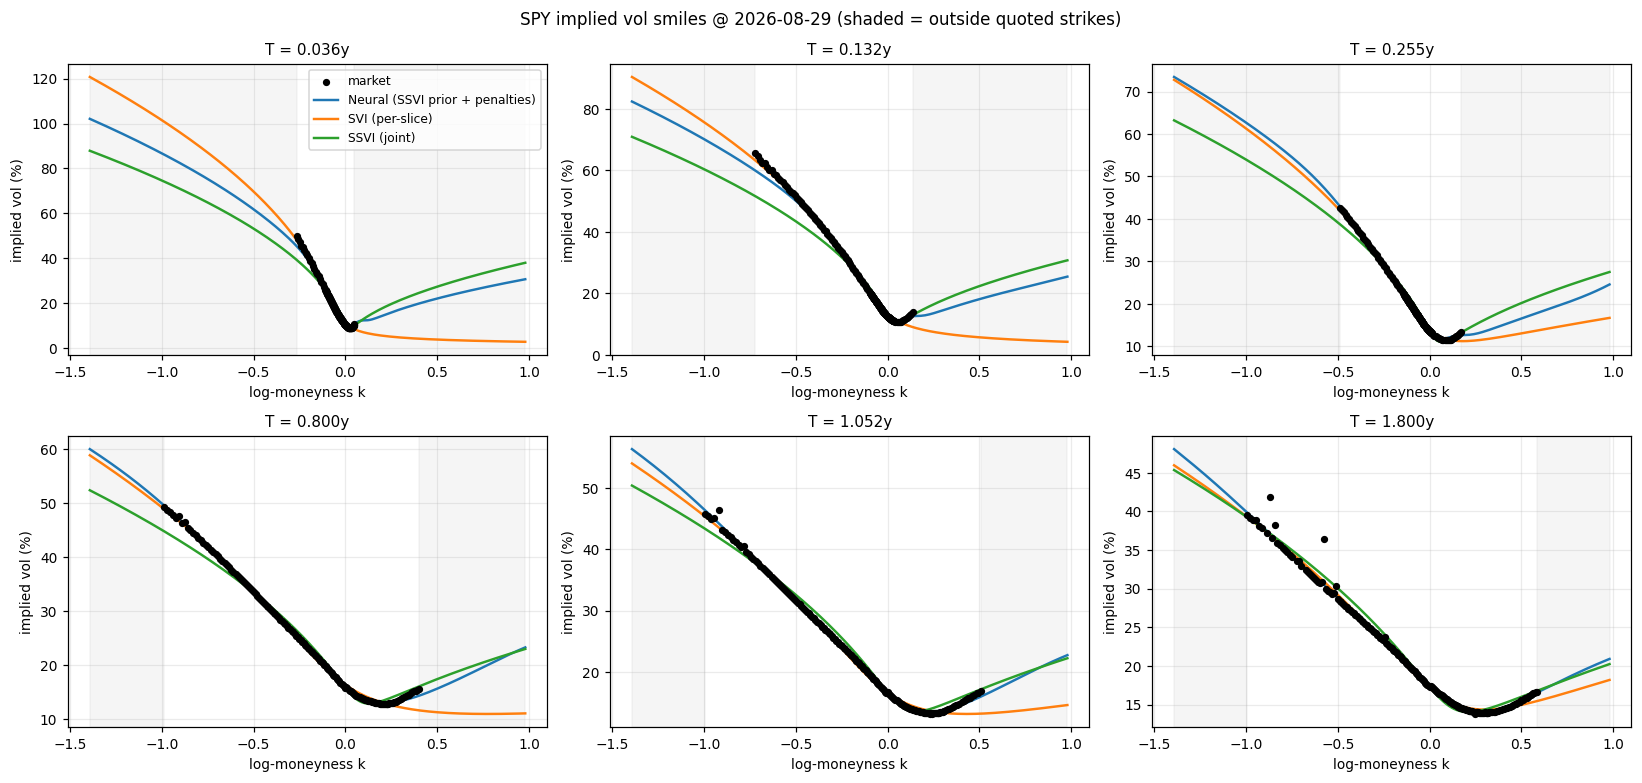

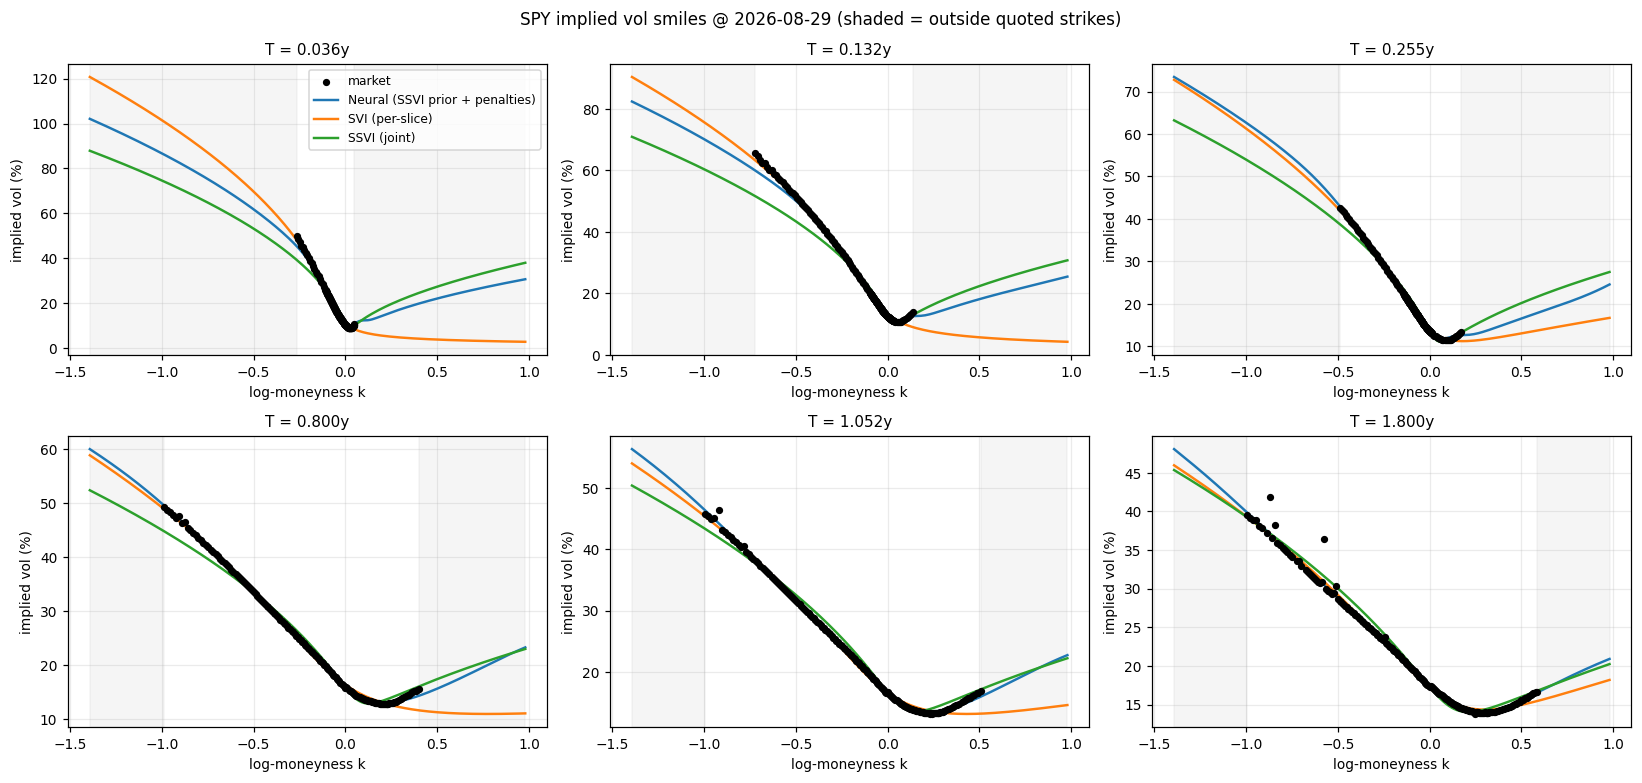

In [15]:
vs.plot_fit(chain, [s.surface for s in scores])

Shaded bands mark the region outside the quoted strikes — where a surface has to
invent. Note how the per-slice SVI wings diverge from the neural surface there,
and that the neural curve stays close to the SSVI prior far from the data,
exactly as the architecture forces it to.

Now the arbitrage maps. Blue is compliant, red is a violation, and the count in
each panel title is measured on the plotted grid.

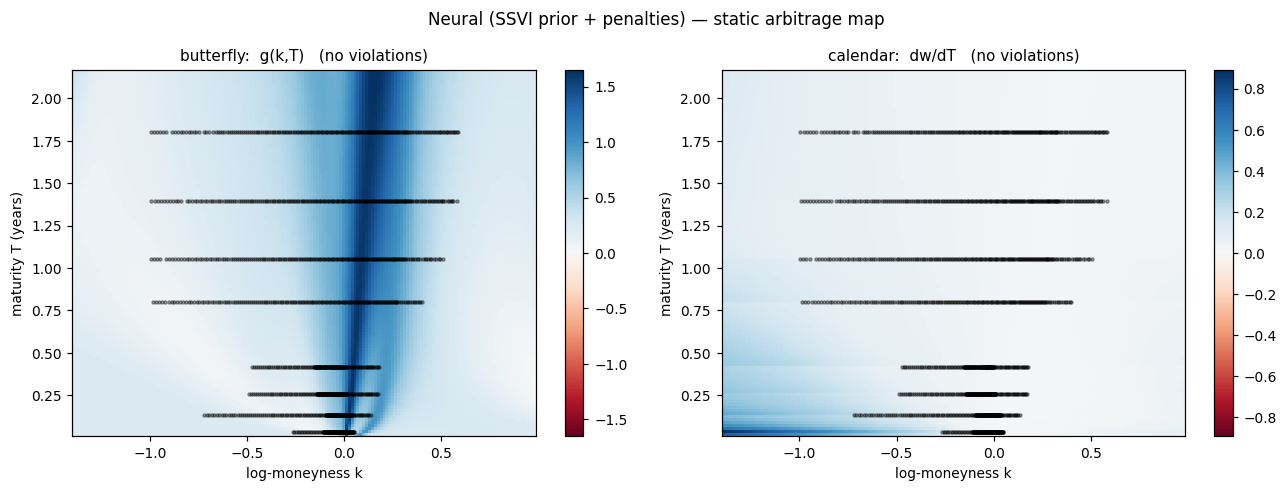

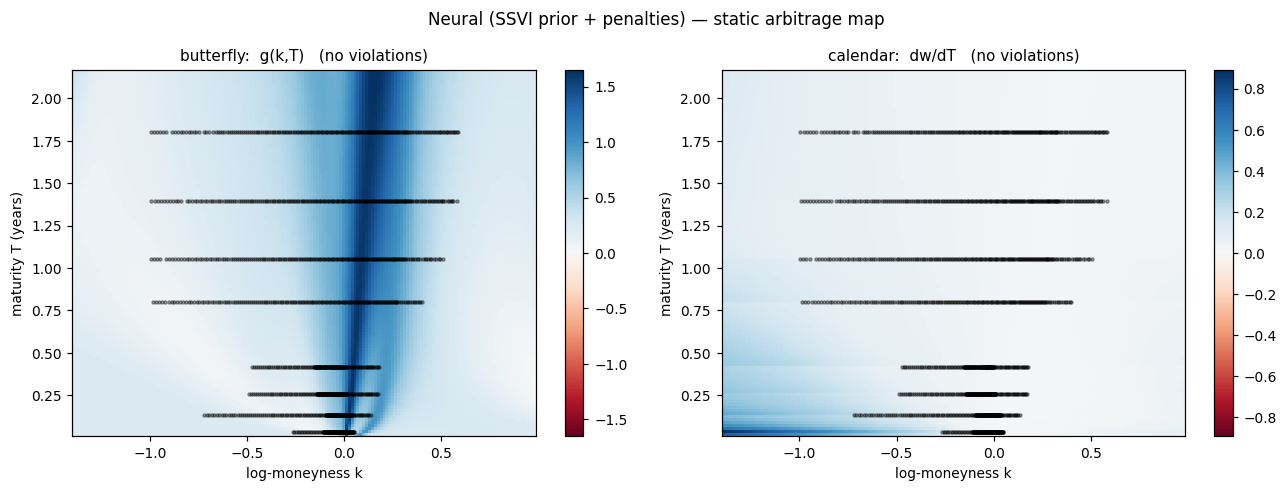

In [16]:
vs.plot_arbitrage_map(result.model, chain)

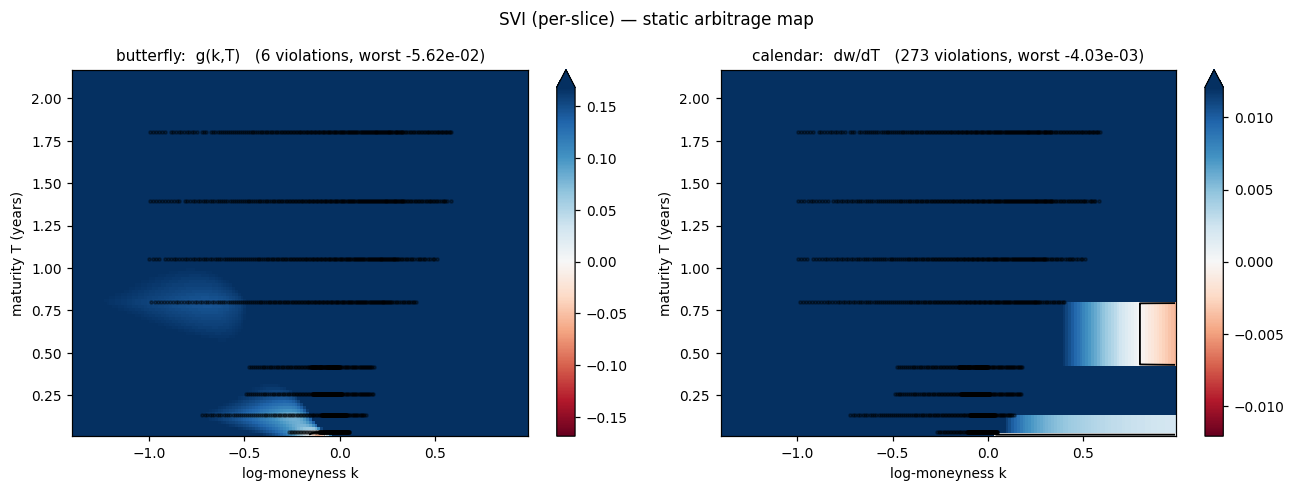

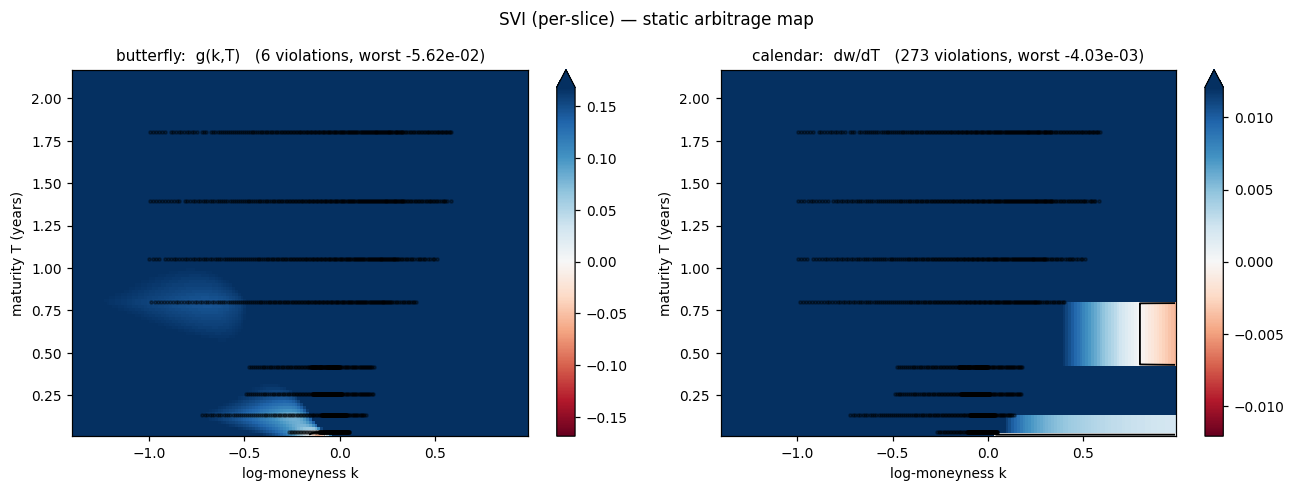

In [17]:
vs.plot_arbitrage_map(svi, chain)

The per-slice construction fails where you would expect: between listed
expiries, and out in the extrapolated wings. Neither region contains a single
quote, which is precisely why fitting alone never reveals the problem.

<a id="7"></a>
## 7. Using the fitted surface

The trained model is a `VolSurface`. Everything below works identically on the
SVI and SSVI objects.

In [18]:
surface = result.model

k = np.array([-0.20, -0.10, 0.0, 0.10, 0.20])
T = np.full_like(k, 0.5)

pd.DataFrame({
    "k": k,
    "implied vol": surface.implied_vol(k, T),
    "total variance": surface.total_variance(k, T),
    "dw/dT (>= 0)": surface.dw_dT(k, T),
    "Durrleman g (>= 0)": vs.diagnostics.butterfly_g(surface, k, T),
})

,k,implied vol,total variance,dw/dT (>= 0),Durrleman g (>= 0)
0,-0.2,0.240031,0.028807,0.049076,0.332397
1,-0.1,0.193188,0.018661,0.040073,0.650641
2,0.0,0.149731,0.011210,0.030723,1.047350
3,0.1,0.125311,0.007851,0.020573,1.178783
4,0.2,0.127791,0.008165,0.018427,0.950788


Pricing a strike that is **not listed**. The forward and discount factor are
interpolated from the ones the chain implied, so the price is consistent with
the market's own forward rather than with an assumed rate.

In [19]:
def price_off_surface(surface, chain, strike, T, option="call"):
    Ts = chain.maturities
    F  = float(np.interp(T, Ts, [chain.forwards[t] for t in Ts]))
    DF = float(np.interp(T, Ts, [chain.discounts[t] for t in Ts]))
    k  = float(np.log(strike / F))
    sigma = float(surface.implied_vol(np.array([k]), np.array([T]))[0])
    px = DF * vs.price(F, strike, T, 0.0, sigma, option)   # S=F, r=0 -> forward measure
    g  = vs.greeks(F, strike, T, 0.0, sigma)
    return {"strike": strike, "T": T, "forward": F, "k": k,
            "implied vol": sigma, "price": px,
            "delta": g["delta_call"] if option == "call" else g["delta_put"],
            "vega": g["vega"], "gamma": g["gamma"]}

atm = chain.spot
pd.DataFrame([price_off_surface(surface, chain, K, 0.42)
              for K in np.round(atm * np.array([0.90, 0.95, 1.00, 1.05, 1.10]), 2)])

,strike,T,forward,k,implied vol,price,delta,vega,gamma
0,693.99,0.42,779.456118,-0.116139,0.199506,94.582309,0.832200,1.267635,0.002490
1,732.54,0.42,779.456118,-0.062078,0.173512,62.088294,0.728500,1.674865,0.003783
2,771.10,0.42,779.456118,-0.010778,0.149499,34.154066,0.563437,1.989706,0.005216
3,809.65,0.42,779.456118,0.038006,0.128474,13.920824,0.339131,1.849088,0.005640
4,848.21,0.42,779.456118,0.084532,0.121510,4.604906,0.150549,1.180663,0.003808


Saving and reloading. The checkpoint carries the network weights *and* the
calibrated SSVI prior, so a reloaded model is byte-for-byte the surface that was
fitted.

In [20]:
from pathlib import Path
Path("results").mkdir(exist_ok=True)
surface.save("results/notebook_surface.pt")

reloaded = vs.NeuralVolSurface.load("results/notebook_surface.pt")
assert np.allclose(reloaded.total_variance(k, T), surface.total_variance(k, T))
print("reloaded surface matches to machine precision")

reloaded surface matches to machine precision


<a id="8"></a>
## 8. Reproducing this

```bash
pip install -e .        # numpy, scipy, pandas, torch, matplotlib, yfinance
python main.py          # the whole study; or press Run in your editor
pytest                  # 72 tests, no network required
```

`main.py` takes no arguments by design — every setting lives in `config.py`, so
a run is reproducible by reading one file rather than by remembering which flags
were passed. It writes `results/report.txt`, the smile figure, and one arbitrage
map per surface.

See [`docs/USAGE.md`](docs/USAGE.md) for the full command and API reference.

---

### What this notebook establishes

1. A neural surface built as a **bounded correction to an arbitrage-free prior**
   fits a real chain substantially better than either parametric baseline while
   remaining free of static arbitrage — including in the regions where no
   options trade.
2. **Positivity, extrapolation behaviour and an error bound are architectural**,
   not products of the optimiser converging nicely. They hold for any weights.
3. **The data pipeline carries as much of the result as the model.** The
   early-exercise premium in American quotes is a larger effect than the fit
   error being measured, and it also biases the forward through put-call parity.

### References

- Gatheral (2004), *A parsimonious arbitrage-free implied volatility parameterization*
- Gatheral & Jacquier (2014), *Arbitrage-Free SVI Volatility Surfaces*, **Quantitative Finance** 14(1)
- Roper (2010), *Arbitrage Free Implied Volatility Surfaces*
- Zeliade Systems (2009), *Quasi-Explicit Calibration of Gatheral's SVI Model*
- Ackerer, Tagasovska & Vatter (2020), *Deep Smoothing of the Implied Volatility Surface*
- Durrleman (2010), *From implied to spot volatilities*